# 🌲 SAST Prototype — Stage 3: Random Forest Classifier
**MTech Project | Static Analysis Security Tool**

```
Java / Python File
        ↓
   Tokenizer
        ↓
     TF-IDF
        ↓
  Random Forest    ← YOU ARE HERE
        ↓
Safe / Vulnerable
```

This notebook trains the **Random Forest** classifier, evaluates it, and saves the model.

## 📦 1. Imports

In [1]:
import os

print("SSL_CERT_FILE =", os.environ.get("SSL_CERT_FILE"))
print("REQUESTS_CA_BUNDLE =", os.environ.get("REQUESTS_CA_BUNDLE"))
print("PIP_CERT =", os.environ.get("PIP_CERT"))

SSL_CERT_FILE = C:\Users\Tejal\miniconda3\Library\ssl\cacert.pem
REQUESTS_CA_BUNDLE = None
PIP_CERT = None


In [2]:
import os

os.environ["REQUESTS_CA_BUNDLE"] = r"C:\Users\Tejal\miniconda3\Library\ssl\cacert.pem"

In [3]:
import os
print(os.environ.get("REQUESTS_CA_BUNDLE"))

C:\Users\Tejal\miniconda3\Library\ssl\cacert.pem


In [4]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.Requirement already satisfied: seaborn in c:\users\tejal\miniconda3\lib\site-packages (0.13.2)



In [5]:
import re
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, roc_auc_score,
                              RocCurveDisplay)
from sklearn.model_selection import (StratifiedKFold, cross_val_score,
                                     train_test_split, learning_curve)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelBinarizer

RANDOM_STATE = 42
print("✅ Imports done.")

✅ Imports done.


## 🔧 2. Tokenizer (reused)

In [6]:
def _remove_block_comments(code):
    return re.sub(r"/\*.*?\*/", " ", code, flags=re.DOTALL)
def _remove_single_line_comments(code):
    return re.sub(r"(//|#)[^\n]*", " ", code)
def _remove_string_literals(code):
    code = re.sub(r'"(?:[^"\\]|\\.)*"', " STRING_LITERAL ", code)
    code = re.sub(r"'(?:[^'\\]|\\.)*'", " STRING_LITERAL ", code)
    return code
def _split_camel_case(token):
    return re.sub(r"([a-z])([A-Z])", r"\1 \2", token)
def tokenize(code):
    code = _remove_block_comments(code)
    code = _remove_single_line_comments(code)
    code = _remove_string_literals(code)
    tokens = re.findall(r"[A-Za-z_][A-Za-z0-9_]*", code)
    expanded = []
    for tok in tokens:
        for sub in _split_camel_case(tok).split():
            sub = sub.lower()
            if len(sub) >= 2:
                expanded.append(sub)
    return " ".join(expanded)

print("✅ Tokenizer ready.")

✅ Tokenizer ready.


## 📂 3. Load Dataset & Prepare Features

In [7]:
df = pd.read_csv("dataset.csv")
df["tokens"] = df["code_snippet"].fillna("").apply(tokenize)

X_raw = df["tokens"]
y     = df["label"]

print(f"Total samples : {len(df):,}")
print(df["label"].value_counts())

Total samples : 1,200
label
safe                300
insecure_api        300
sql_injection       300
hardcoded_secret    300
Name: count, dtype: int64


## ✂️ 4. Train / Test Split (80/20 Stratified)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)
print(f"Train: {len(X_train):,}  |  Test: {len(X_test):,}")

Train: 960  |  Test: 240


## 🏗️ 5. Build TF-IDF + Random Forest Pipeline

In [9]:
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        analyzer="word",
        ngram_range=(1, 3),
        max_features=10_000,
        sublinear_tf=True,
        min_df=2,
    )),
    ("rf", RandomForestClassifier(
        n_estimators=200,
        max_features="sqrt",
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

print(pipeline)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=10000, min_df=2,
                                 ngram_range=(1, 3), sublinear_tf=True)),
                ('rf',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=200, n_jobs=-1,
                                        random_state=42))])


## 🚀 6. Train the Model

In [10]:
%%time
pipeline.fit(X_train, y_train)
print("\n✅ Training complete!")


✅ Training complete!
CPU times: total: 609 ms
Wall time: 521 ms


## 📊 7. Classification Report

In [11]:
y_pred = pipeline.predict(X_test)
classes = pipeline.classes_

print("=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_test, y_pred, target_names=classes))

CLASSIFICATION REPORT
                  precision    recall  f1-score   support

hardcoded_secret       1.00      1.00      1.00        60
    insecure_api       1.00      1.00      1.00        60
            safe       1.00      1.00      1.00        60
   sql_injection       1.00      1.00      1.00        60

        accuracy                           1.00       240
       macro avg       1.00      1.00      1.00       240
    weighted avg       1.00      1.00      1.00       240



## 🔳 8. Confusion Matrix

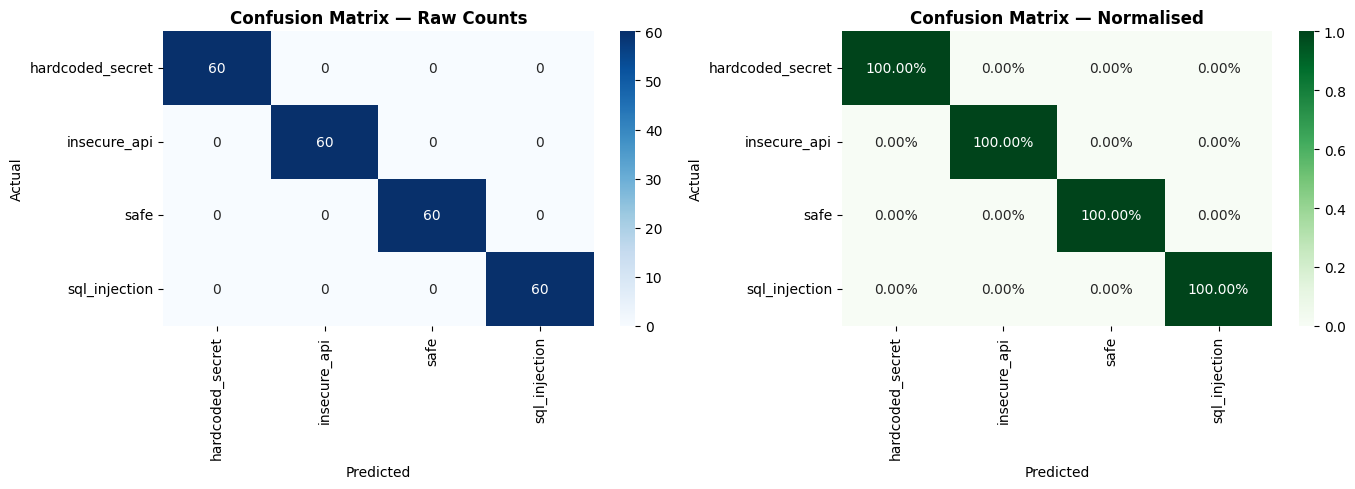

In [12]:
cm  = confusion_matrix(y_test, y_pred, labels=classes)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes, yticklabels=classes, ax=axes[0])
axes[0].set_title("Confusion Matrix — Raw Counts", fontweight="bold")
axes[0].set_ylabel("Actual")
axes[0].set_xlabel("Predicted")

# Normalised
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt=".2%", cmap="Greens",
            xticklabels=classes, yticklabels=classes, ax=axes[1])
axes[1].set_title("Confusion Matrix — Normalised", fontweight="bold")
axes[1].set_ylabel("Actual")
axes[1].set_xlabel("Predicted")

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=120, bbox_inches="tight")
plt.show()

## 🔄 9. 5-Fold Cross-Validation

In [13]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scores = cross_val_score(pipeline, X_raw, y, cv=cv,
                         scoring="f1_macro", n_jobs=-1)

print("5-Fold Stratified Cross-Validation (F1-Macro)")
print("-" * 45)
for i, s in enumerate(scores, 1):
    bar = "█" * int(s * 30)
    print(f"  Fold {i}: {s:.4f}  {bar}")
print("-" * 45)
print(f"  Mean : {scores.mean():.4f}")
print(f"  Std  : {scores.std():.4f}")

5-Fold Stratified Cross-Validation (F1-Macro)
---------------------------------------------
  Fold 1: 1.0000  ██████████████████████████████
  Fold 2: 1.0000  ██████████████████████████████
  Fold 3: 1.0000  ██████████████████████████████
  Fold 4: 1.0000  ██████████████████████████████
  Fold 5: 1.0000  ██████████████████████████████
---------------------------------------------
  Mean : 1.0000
  Std  : 0.0000


## 🌟 10. Feature Importance — Top 20 Tokens

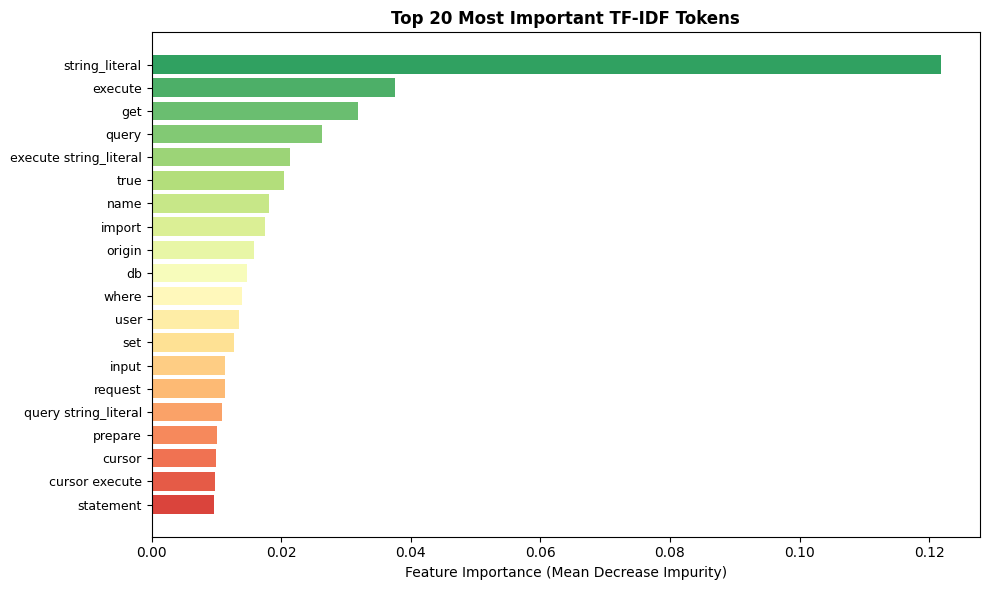

In [14]:
feature_names = np.array(pipeline["tfidf"].get_feature_names_out())
importances   = pipeline["rf"].feature_importances_
top20_idx     = np.argsort(importances)[::-1][:20]

fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, 20))
ax.barh(range(20), importances[top20_idx][::-1], color=colors[::-1], alpha=0.9)
ax.set_yticks(range(20))
ax.set_yticklabels(feature_names[top20_idx][::-1], fontsize=9)
ax.set_xlabel("Feature Importance (Mean Decrease Impurity)")
ax.set_title("Top 20 Most Important TF-IDF Tokens", fontweight="bold")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=120, bbox_inches="tight")
plt.show()

## 📈 11. Learning Curve

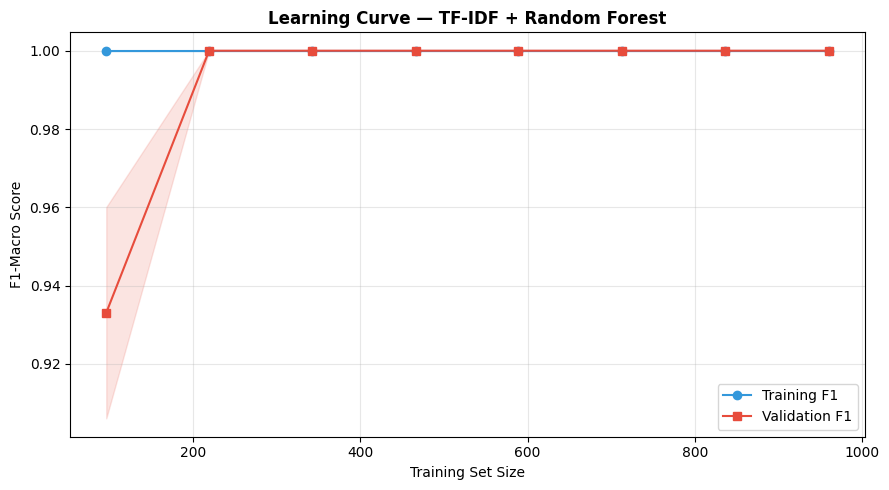

In [15]:
train_sizes, train_scores, val_scores = learning_curve(
    pipeline, X_raw, y,
    cv=5, scoring="f1_macro",
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1,
)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(train_sizes, train_scores.mean(axis=1), "o-", color="#3498db", label="Training F1")
ax.fill_between(train_sizes,
                train_scores.mean(axis=1) - train_scores.std(axis=1),
                train_scores.mean(axis=1) + train_scores.std(axis=1), alpha=0.15, color="#3498db")
ax.plot(train_sizes, val_scores.mean(axis=1), "s-", color="#e74c3c", label="Validation F1")
ax.fill_between(train_sizes,
                val_scores.mean(axis=1) - val_scores.std(axis=1),
                val_scores.mean(axis=1) + val_scores.std(axis=1), alpha=0.15, color="#e74c3c")
ax.set_xlabel("Training Set Size")
ax.set_ylabel("F1-Macro Score")
ax.set_title("Learning Curve — TF-IDF + Random Forest", fontweight="bold")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("learning_curve.png", dpi=120, bbox_inches="tight")
plt.show()

## 💾 12. Save Model

In [16]:
os.makedirs("models", exist_ok=True)
joblib.dump(pipeline, "models/sast_pipeline.joblib")
joblib.dump(list(classes), "models/label_classes.joblib")
print("✅ Model saved → models/sast_pipeline.joblib")
print("✅ Labels saved → models/label_classes.joblib")

✅ Model saved → models/sast_pipeline.joblib
✅ Labels saved → models/label_classes.joblib
